# v4.2 Risk-Increase Confirmation Ablation

This notebook follows the state-2 tail diagnostic. It separates:

- a **mechanical one-session execution delay**;
- one-session confirmation on the `0→1` bridge entry;
- one-session confirmation on the `1→2` leverage entry;
- confirmation on both risk-increasing transitions.

No price, VIX, VXN, allocation, TQQQ weight, or official cost parameter is changed.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("artifacts/evidence/qqqi_qqq_tqqq_v4_2_risk_confirmation_v4_3_research")
summary = json.loads((ROOT / "confirmation_summary.json").read_text(encoding="utf-8"))
metrics = pd.read_csv(ROOT / "confirmation_metrics.csv", index_col=0)
segments = pd.read_csv(ROOT / "confirmation_chronological_segments.csv")
events = pd.read_csv(ROOT / "confirmation_difference_events.csv", parse_dates=["start_date", "end_date"])
event_summary = pd.read_csv(ROOT / "confirmation_event_summary.csv")

summary["economic_sample"], summary["research_gate"]

({'end_date': '2026-07-30', 'observations': 627, 'start_date': '2024-01-30'},
 {'gates': {'cagr_improves': True,
   'calmar_improves': True,
   'early_segment_positive': True,
   'late_segment_positive': False,
   'max_drawdown_within_tolerance': True,
   'positive_event_rate': False,
   'sharpe_improves': True,
   'sortino_improves': True,
   'top_event_not_dominant': True,
   'turnover_not_higher': True},
  'measured': {'early_segment_cagr_delta': 0.03865360633435899,
   'late_segment_cagr_delta': -0.013926218548510061,
   'positive_event_rate': 0.5,
   'top_positive_event_share': 0.42564038506089763,
   'turnover_delta': -18.0},
  'next_direction': 'retain_v4_2_and_reject_confirmation_challenger',
  'passes_retrospective_research_gate': False,
  'promotion_authorized': False})

## 1. Full-sample comparison

In [2]:
metrics[[
    "total_return", "cagr", "annual_volatility", "sharpe", "sortino",
    "max_drawdown", "calmar", "turnover_units", "state_2_sessions",
    "cagr_delta_vs_baseline", "max_drawdown_delta_vs_baseline",
]]

,total_return,cagr,annual_volatility,sharpe,sortino,max_drawdown,calmar,turnover_units,state_2_sessions,cagr_delta_vs_baseline,max_drawdown_delta_vs_baseline
strategy,,,,,,,,,,,
all_transitions_confirmation_1,1.137416,0.357022,0.251102,1.342121,1.968947,-0.271548,1.314764,34.0,123,0.026448,-2.941400e-02
baseline,1.035264,0.330574,0.256204,1.243717,1.801463,-0.242134,1.365249,55.0,129,0.000000,0.000000e+00
bridge_entry_confirmation_1,1.012929,0.324686,0.255862,1.227690,1.775562,-0.242282,1.340116,54.0,129,-0.005888,-1.473482e-04
fixed_execution_delay_1,1.046272,0.333461,0.252672,1.265981,1.846406,-0.271548,1.228000,54.0,129,0.002888,-2.941400e-02
leverage_entry_confirmation_1,1.135071,0.356424,0.247972,1.354061,1.998419,-0.242134,1.472008,37.5,117,0.025850,5.551115e-16
risk_increase_confirmation_1,1.109981,0.349995,0.247618,1.336440,1.969115,-0.242282,1.444577,37.0,117,0.019421,-1.473482e-04
risk_reduction_confirmation_1,1.031557,0.329599,0.260851,1.223440,1.759547,-0.271407,1.214410,43.0,141,-0.000975,-2.927234e-02


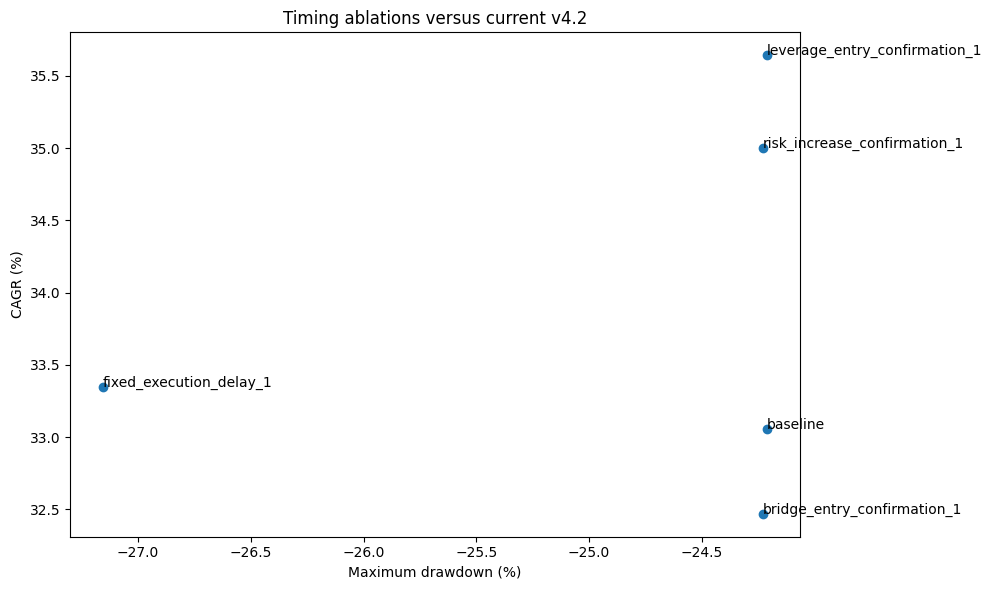

In [3]:
focus = metrics.loc[[
    "baseline", "fixed_execution_delay_1",
    "bridge_entry_confirmation_1", "leverage_entry_confirmation_1",
    "risk_increase_confirmation_1",
]]
plt.figure(figsize=(10, 6))
plt.scatter(focus["max_drawdown"] * 100, focus["cagr"] * 100)
for name, row in focus.iterrows():
    plt.annotate(name, (row["max_drawdown"] * 100, row["cagr"] * 100))
plt.xlabel("Maximum drawdown (%)")
plt.ylabel("CAGR (%)")
plt.title("Timing ablations versus current v4.2")
plt.tight_layout()
plt.show()

## 2. Chronological stability

In [4]:
segments.pivot_table(
    index="strategy",
    columns="segment",
    values=["cagr", "sharpe", "max_drawdown", "calmar"],
)

cagr              calmar            \
segment                            early      late     early      late   
strategy                                                                 
all_transitions_confirmation_1  0.269933  0.498783  0.994050  3.414559   
baseline                        0.246773  0.466764  1.019155  3.016534   
bridge_entry_confirmation_1     0.241410  0.460001  0.996400  2.968963   
fixed_execution_delay_1         0.259912  0.451749  0.957149  3.092575   
leverage_entry_confirmation_1   0.291660  0.459567  1.204536  2.970022   
risk_increase_confirmation_1    0.285426  0.452838  1.178075  2.922726   
risk_reduction_confirmation_1   0.240832  0.474594  0.887348  3.253500   

                               max_drawdown              sharpe            
segment                               early      late     early      late  
strategy                                                                   
all_transitions_confirmation_1    -0.271548 -0.146075  1.026329  1.923656  
baseline                          -0.242134 -0.154735  0.937324  1.831135  
bridge_entry_confirmation_1       -0.242282 -0.154937  0.922301  1.813998  
fixed_execution_delay_1           -0.271548 -0.146075  0.995776  1.754938  
leverage_entry_confirmation_1     -0.242134 -0.154735  1.101458  1.818524  
risk_increase_confirmation_1      -0.242282 -0.154937  1.083959  1.801284  
risk_reduction_confirmation_1     -0.271407 -0.145872  0.910978  1.812957

## 3. Event attribution and concentration

In [5]:
event_summary

,scenario,events,positive_event_rate,mean_net_return_delta,total_arithmetic_net_return_delta,top_positive_event_share,total_turnover_saved
0,bridge_entry_confirmation_1,10,0.600000,-0.000226,-0.002260,0.361167,10.0
1,leverage_entry_confirmation_1,12,0.416667,0.003592,0.043107,0.450171,18.0
2,risk_increase_confirmation_1,20,0.500000,0.002103,0.042069,0.425640,29.5


In [6]:
events.sort_values(
    ["scenario", "net_return_delta"], ascending=[True, False]
).head(40)

,scenario,event_id,start_date,end_date,sessions,baseline_states,challenger_states,baseline_net_return,challenger_net_return,net_return_delta,baseline_turnover_units,challenger_turnover_units,turnover_saved
5,bridge_entry_confirmation_1,6,2025-05-05,2025-05-05,1,1,0,-0.009921,-0.007443,0.002479,1.0,0.0,1.0
7,bridge_entry_confirmation_1,8,2025-08-07,2025-08-07,1,1,0,-0.002537,-0.000940,0.001597,1.0,0.0,1.0
0,bridge_entry_confirmation_1,1,2024-08-14,2024-08-14,1,1,0,0.010165,0.011004,0.000839,1.0,0.0,1.0
4,bridge_entry_confirmation_1,5,2025-03-25,2025-03-25,1,1,0,0.000678,0.001505,0.000826,1.0,0.0,1.0
9,bridge_entry_confirmation_1,10,2026-06-15,2026-06-15,1,1,0,0.004397,0.005171,0.000774,1.0,0.0,1.0
1,bridge_entry_confirmation_1,2,2024-09-13,2024-09-13,1,1,0,-0.000149,0.000199,0.000348,1.0,0.0,1.0
2,bridge_entry_confirmation_1,3,2024-10-25,2024-10-25,1,1,0,0.004098,0.003491,-0.000607,1.0,0.0,1.0
3,bridge_entry_confirmation_1,4,2024-11-07,2024-11-07,1,1,0,0.006032,0.004937,-0.001095,1.0,0.0,1.0
6,bridge_entry_confirmation_1,7,2025-05-09,2025-05-09,1,1,0,0.028899,0.025568,-0.003331,1.0,0.0,1.0
8,bridge_entry_confirmation_1,9,2026-04-07,2026-04-07,1,1,0,0.033303,0.029213,-0.004090,1.0,0.0,1.0


## 4. Research gate

In [7]:
gate = summary["research_gate"]
pd.Series(gate["gates"], name="passed").to_frame().join(
    pd.Series(gate["measured"], name="measured")
)

,passed,measured
cagr_improves,True,NaN
calmar_improves,True,NaN
early_segment_positive,True,NaN
late_segment_positive,False,NaN
max_drawdown_within_tolerance,True,NaN
positive_event_rate,False,0.5
sharpe_improves,True,NaN
sortino_improves,True,NaN
top_event_not_dominant,True,NaN
turnover_not_higher,True,NaN


In [8]:
print("Retrospective gate passed:", gate["passes_retrospective_research_gate"])
print("Direct promotion authorized:", gate["promotion_authorized"])
print("Next direction:", gate["next_direction"])

Retrospective gate passed: False
Direct promotion authorized: False
Next direction: retain_v4_2_and_reject_confirmation_challenger
